# Walmart M5 Exploratory Data Analysis

## Business Objective
Notebook 01 established the structure and quality of the source data. This notebook studies **business and forecasting behavior** before feature engineering.

We will explore overall demand, seasonality, geography, product hierarchy, intermittent demand, prices, events/holidays, SNAP, weather, economics, and candidate forecasting features.

> This is EDA, not modeling. Findings here will guide Notebook 03.

## 1. Import Libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Define Project Paths

We use the M5 evaluation history plus the external datasets already produced by the extraction scripts. To control memory, we avoid melting the entire sales history at once.

In [2]:
PROJECT_ROOT = Path("..")
RAW_DIR = PROJECT_ROOT / "data" / "raw"
EXTERNAL_DIR = PROJECT_ROOT / "data" / "external"

CALENDAR_FILE = RAW_DIR / "calendar.csv"
PRICES_FILE = RAW_DIR / "sell_prices.csv"
SALES_FILE = RAW_DIR / "sales_train_evaluation.csv"
FRED_FILE = EXTERNAL_DIR / "fred_economic_data.csv"
HOLIDAYS_FILE = EXTERNAL_DIR / "us_holidays.csv"
WEATHER_FILE = EXTERNAL_DIR / "weather_history.csv"

## 3. Load Analysis Data

`sample_submission.csv` is excluded because it describes forecast-output structure rather than historical business behavior.

In [3]:
calendar = pd.read_csv(CALENDAR_FILE)
prices = pd.read_csv(PRICES_FILE)
sales = pd.read_csv(SALES_FILE)
fred = pd.read_csv(FRED_FILE)
holidays = pd.read_csv(HOLIDAYS_FILE)
weather = pd.read_csv(WEATHER_FILE)

calendar["date"] = pd.to_datetime(calendar["date"])
fred["date"] = pd.to_datetime(fred["date"])
holidays["date"] = pd.to_datetime(holidays["date"])
weather["time"] = pd.to_datetime(weather["time"])

day_columns = [c for c in sales.columns if c.startswith("d_")]

for name, df in {"calendar":calendar,"prices":prices,"sales":sales,"fred":fred,"holidays":holidays,"weather":weather}.items():
    print(f"{name.upper():10} {df.shape}")
print("Sales day columns:", len(day_columns))

CALENDAR   (1969, 14)
PRICES     (6841121, 4)
SALES      (30490, 1947)
FRED       (198, 3)
HOLIDAYS   (65, 2)
WEATHER    (5907, 7)
Sales day columns: 1941


## 4. Create Lightweight Analysis Tables

Create daily totals and smaller state/store/category/department tables. This answers most EDA questions without creating the full ~59-million-row long table in memory.

In [4]:
calendar_lookup = calendar[[
    "d","date","wm_yr_wk","weekday","wday","month","year",
    "event_name_1","event_type_1","event_name_2","event_type_2",
    "snap_CA","snap_TX","snap_WI"
]].copy()
calendar_lookup = calendar_lookup[calendar_lookup["d"].isin(day_columns)].copy()

daily_total = (
    sales[day_columns].sum(axis=0).rename("units_sold").rename_axis("d").reset_index()
    .merge(calendar_lookup, on="d", how="left", validate="one_to_one")
    .sort_values("date").reset_index(drop=True)
)
daily_total.head()

,d,units_sold,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,d_1,32631,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,d_2,31749,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,d_3,23783,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,d_4,25412,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,1,1,0
4,d_5,19146,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,1,0,1


In [5]:
def aggregate_sales_by_dimension(sales_df, dimension, day_cols):
    grouped = sales_df[[dimension] + day_cols].groupby(dimension, as_index=False)[day_cols].sum()
    long_df = grouped.melt(id_vars=[dimension], value_vars=day_cols, var_name="d", value_name="units_sold")
    return long_df.merge(calendar_lookup[["d","date"]], on="d", how="left", validate="many_to_one")

daily_state = aggregate_sales_by_dimension(sales, "state_id", day_columns)
daily_store = aggregate_sales_by_dimension(sales, "store_id", day_columns)
daily_category = aggregate_sales_by_dimension(sales, "cat_id", day_columns)
daily_department = aggregate_sales_by_dimension(sales, "dept_id", day_columns)

C:\Users\7800XT\AppData\Local\Temp\ipykernel_41116\30161211.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  grouped = sales_df[[dimension] + day_cols].groupby(dimension, as_index=False)[day_cols].sum()
C:\Users\7800XT\AppData\Local\Temp\ipykernel_41116\30161211.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  grouped = sales_df[[dimension] + day_cols].groupby(dimension, as_index=False)[day_cols].sum()
C:\Users\7800XT\AppData\Local\Temp\ipykernel_41116\30161211.py:2: PerformanceWarning: DataFrame is highly fragmented.  Thi

## 5. Overall Demand Trend

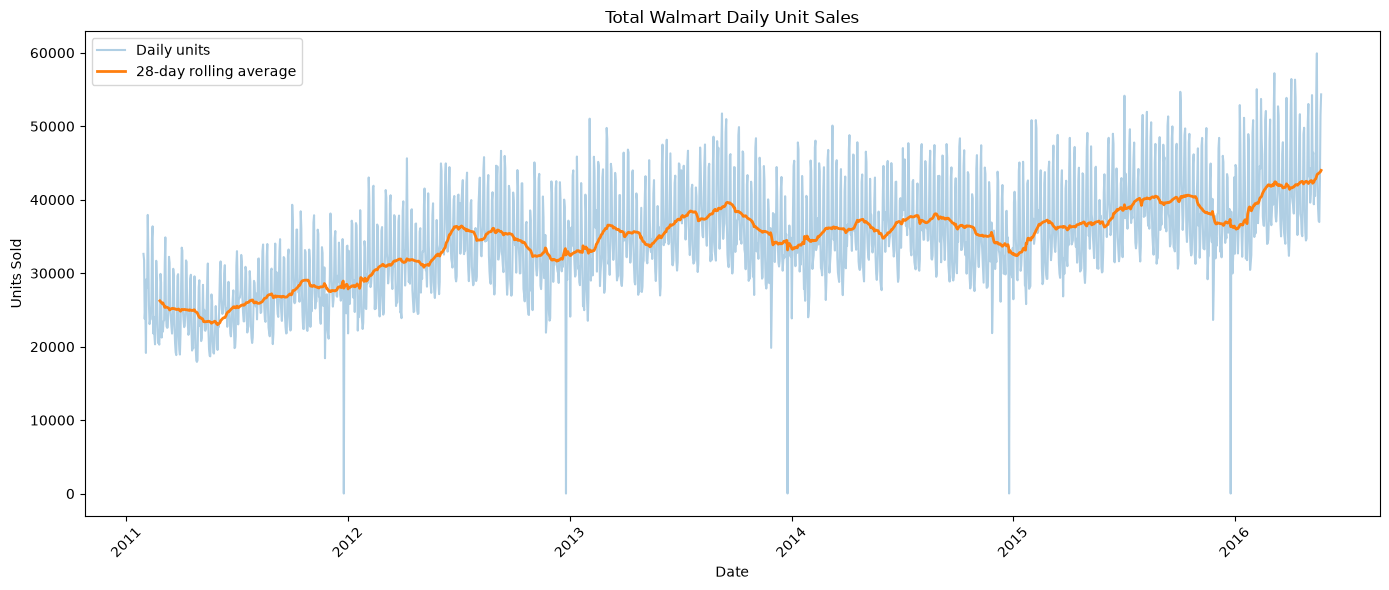

,date,units_sold
1933,2016-05-15,59921
1863,2016-03-06,57218
1891,2016-04-03,56425
1897,2016-04-09,56340
1834,2016-02-06,55040
1708,2015-10-03,54687
1940,2016-05-22,54338
1932,2016-05-14,54308
1925,2016-05-07,54239
1616,2015-07-03,54154


In [6]:
daily_total["rolling_28d"] = daily_total["units_sold"].rolling(28).mean()
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(daily_total["date"], daily_total["units_sold"], alpha=.35, label="Daily units")
ax.plot(daily_total["date"], daily_total["rolling_28d"], linewidth=2, label="28-day rolling average")
ax.set(title="Total Walmart Daily Unit Sales", xlabel="Date", ylabel="Units Sold")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

display(daily_total[["date","units_sold"]].nlargest(10,"units_sold"))

## 6. Day-of-Week Seasonality

,wday,weekday,units_sold
0,1,Saturday,41706.269784
1,2,Sunday,41304.050360
2,3,Monday,32994.931408
3,4,Tuesday,30500.483755
4,5,Wednesday,30130.418773
5,6,Thursday,30321.039711
6,7,Friday,34357.472924


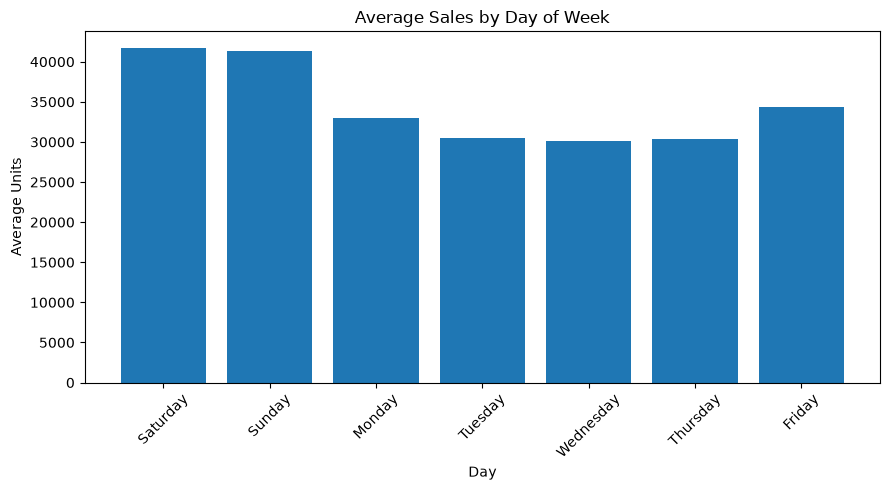

In [7]:
weekday_sales = daily_total.groupby(["wday","weekday"], as_index=False)["units_sold"].mean().sort_values("wday")
display(weekday_sales)
fig, ax = plt.subplots(figsize=(9,5)); ax.bar(weekday_sales["weekday"], weekday_sales["units_sold"]); ax.set(title="Average Sales by Day of Week", xlabel="Day", ylabel="Average Units"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 7. Monthly and Yearly Seasonality

,month,units_sold
0,1,33832.348101
1,2,34644.641176
2,3,34339.838710
3,4,34432.183333
4,5,34085.192090
5,6,35001.413333
6,7,35122.419355
7,8,35946.645161
8,9,35479.260000
9,10,34713.477419


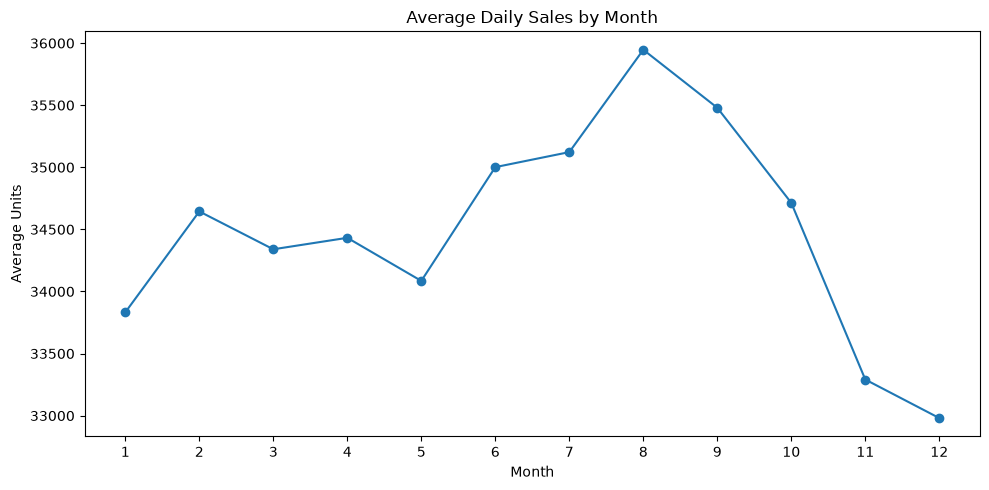

,year,average_daily_sales,total_sales
0,2011,26280.667656,8856585
1,2012,32955.838798,12061837
2,2013,35988.364384,13135753
3,2014,35862.400000,13089776
4,2015,37810.441096,13800811
5,2016,41835.041958,5982411


In [8]:
monthly_sales = daily_total.groupby("month", as_index=False)["units_sold"].mean()
display(monthly_sales)
fig, ax = plt.subplots(figsize=(10,5)); ax.plot(monthly_sales["month"], monthly_sales["units_sold"], marker="o"); ax.set(title="Average Daily Sales by Month", xlabel="Month", ylabel="Average Units"); ax.set_xticks(range(1,13)); plt.tight_layout(); plt.show()

yearly_sales = daily_total.groupby("year", as_index=False)["units_sold"].agg(average_daily_sales="mean", total_sales="sum")
display(yearly_sales)

## 8. State-Level Demand

,state_id,total_units,average_daily_units
0,CA,29196717,15042.100464
1,TX,19228405,9906.442555
2,WI,18502051,9532.226172


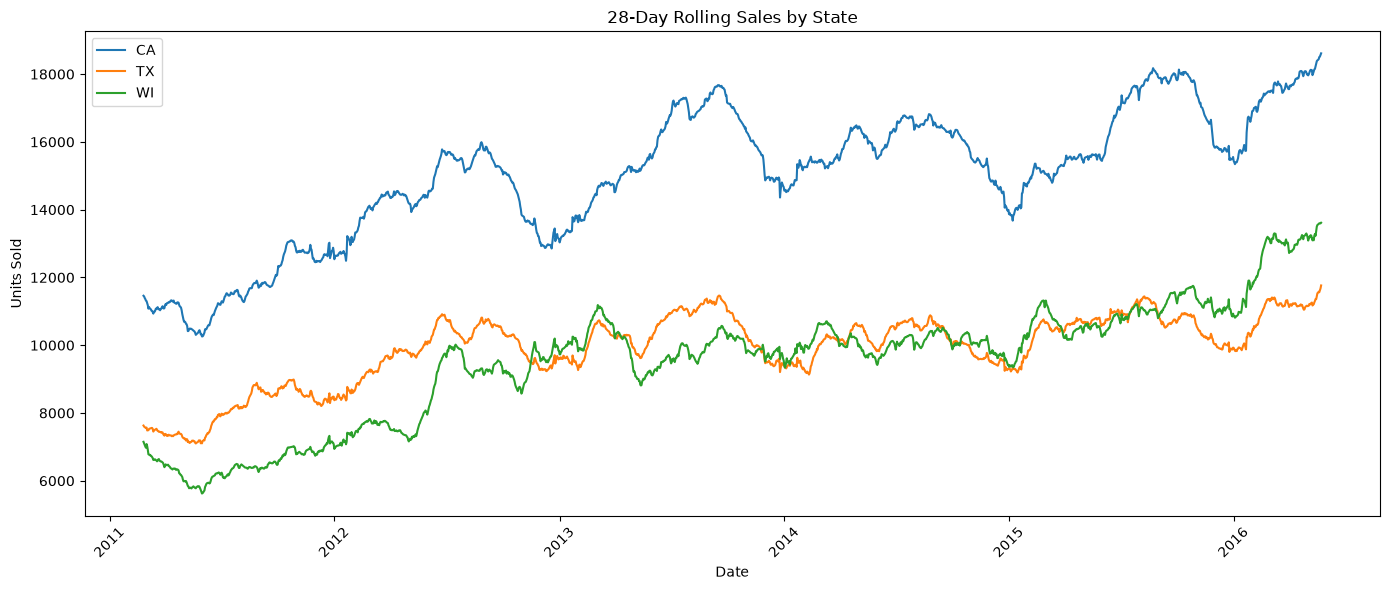

In [9]:
state_summary = daily_state.groupby("state_id", as_index=False)["units_sold"].agg(total_units="sum", average_daily_units="mean").sort_values("total_units", ascending=False)
display(state_summary)
fig, ax = plt.subplots(figsize=(14,6))
for state_id, g in daily_state.groupby("state_id"):
    g=g.sort_values("date"); ax.plot(g["date"], g["units_sold"].rolling(28).mean(), label=state_id)
ax.set(title="28-Day Rolling Sales by State", xlabel="Date", ylabel="Units Sold"); ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 9. Store-Level Demand

,store_id,total_units,average_daily_units,sales_std
2,CA_3,11363540,5854.477074,1197.765435
0,CA_1,7832248,4035.161257,994.891371
5,TX_2,7329642,3776.219474,791.389294
8,WI_2,6697988,3450.792375,1304.984661
9,WI_3,6542557,3370.714580,829.380669
6,TX_3,6205940,3197.290057,689.250751
1,CA_2,5818395,2997.627512,928.407386
4,TX_1,5692823,2932.933024,617.853295
7,WI_1,5261506,2710.719217,1007.099725
3,CA_4,4182534,2154.834621,434.003127


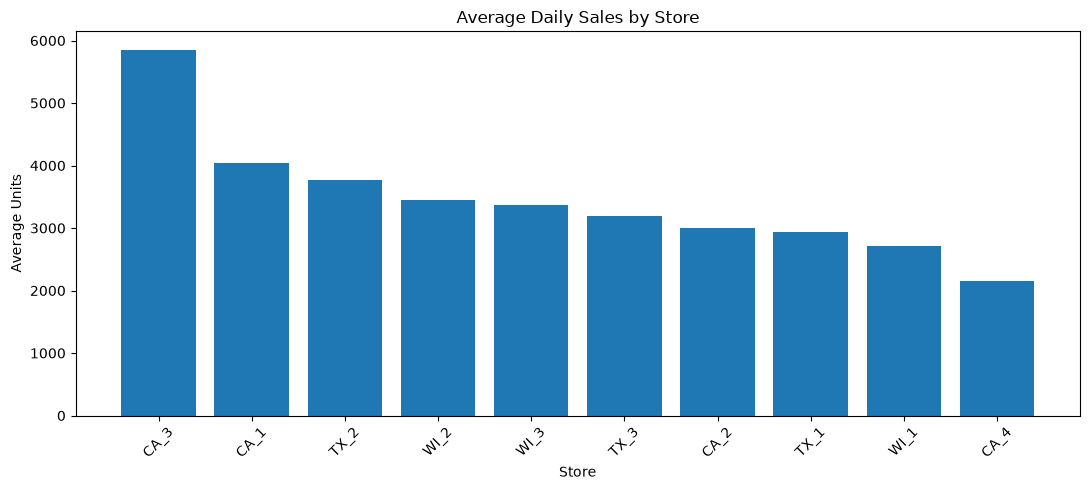

In [10]:
store_summary = daily_store.groupby("store_id", as_index=False)["units_sold"].agg(total_units="sum", average_daily_units="mean", sales_std="std").sort_values("total_units", ascending=False)
display(store_summary)
fig, ax = plt.subplots(figsize=(11,5)); ax.bar(store_summary["store_id"], store_summary["average_daily_units"]); ax.set(title="Average Daily Sales by Store", xlabel="Store", ylabel="Average Units"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 10. Category and Department Demand

,cat_id,total_units,average_daily_units
0,FOODS,45922427,23659.158681
2,HOUSEHOLD,14764090,7606.434827
1,HOBBIES,6240656,3215.175683


,dept_id,total_units,average_daily_units
2,FOODS_3,32937002,16969.089129
5,HOUSEHOLD_1,11722853,6039.594539
1,FOODS_2,7795025,4015.984029
3,HOBBIES_1,5699014,2936.122617
0,FOODS_1,5190400,2674.085523
6,HOUSEHOLD_2,3041237,1566.840289
4,HOBBIES_2,541642,279.053065


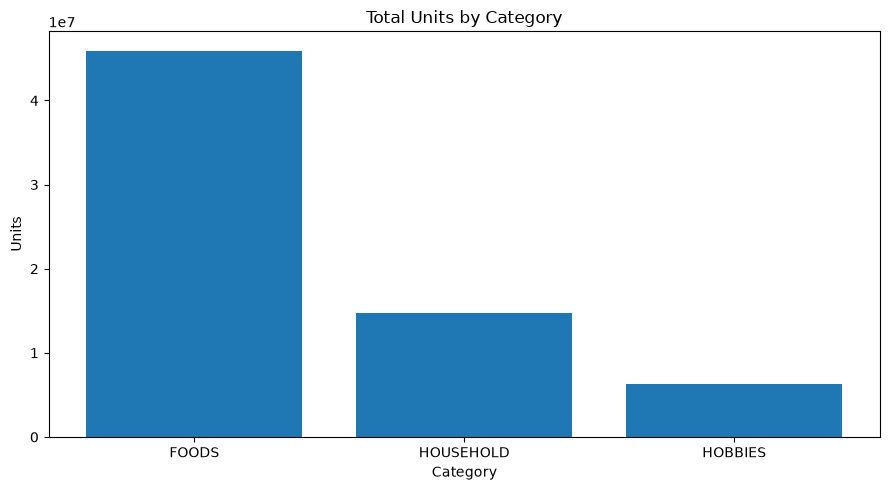

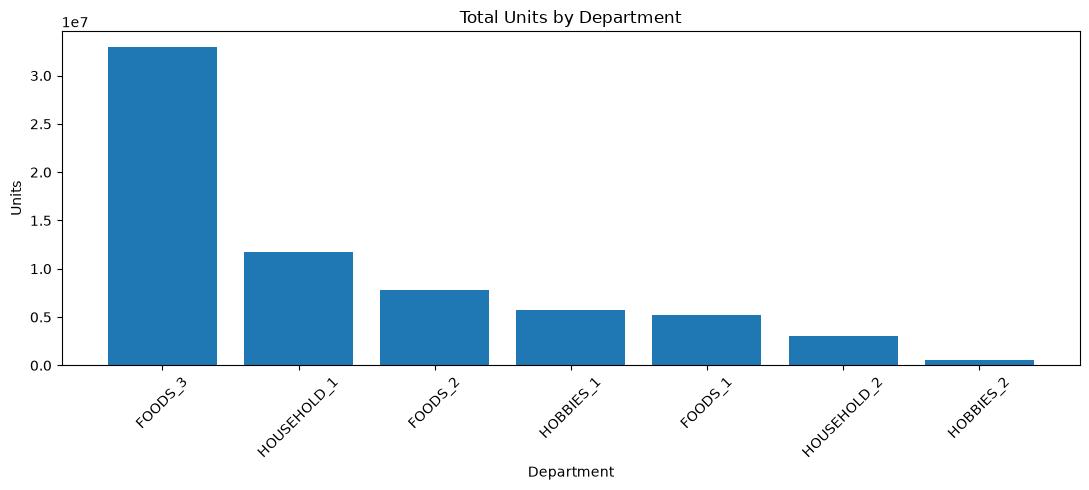

In [11]:
category_summary = daily_category.groupby("cat_id", as_index=False)["units_sold"].agg(total_units="sum", average_daily_units="mean").sort_values("total_units", ascending=False)
department_summary = daily_department.groupby("dept_id", as_index=False)["units_sold"].agg(total_units="sum", average_daily_units="mean").sort_values("total_units", ascending=False)
display(category_summary); display(department_summary)
fig, ax = plt.subplots(figsize=(9,5)); ax.bar(category_summary["cat_id"], category_summary["total_units"]); ax.set(title="Total Units by Category", xlabel="Category", ylabel="Units"); plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(11,5)); ax.bar(department_summary["dept_id"], department_summary["total_units"]); ax.set(title="Total Units by Department", xlabel="Department", ylabel="Units"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 11. Product Demand Distribution

C:\Users\7800XT\AppData\Local\Temp\ipykernel_41116\1875528026.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  product_totals = sales[["item_id"] + day_columns].groupby("item_id", as_index=False)[day_columns].sum()


,item_id,total_units
0,FOODS_3_090,1017916
1,FOODS_3_586,932236
2,FOODS_3_252,573723
3,FOODS_3_555,497881
4,FOODS_3_587,402159
5,FOODS_3_714,402111
6,FOODS_3_694,395937
7,FOODS_3_226,368369
8,FOODS_3_202,300529
9,FOODS_3_120,290132


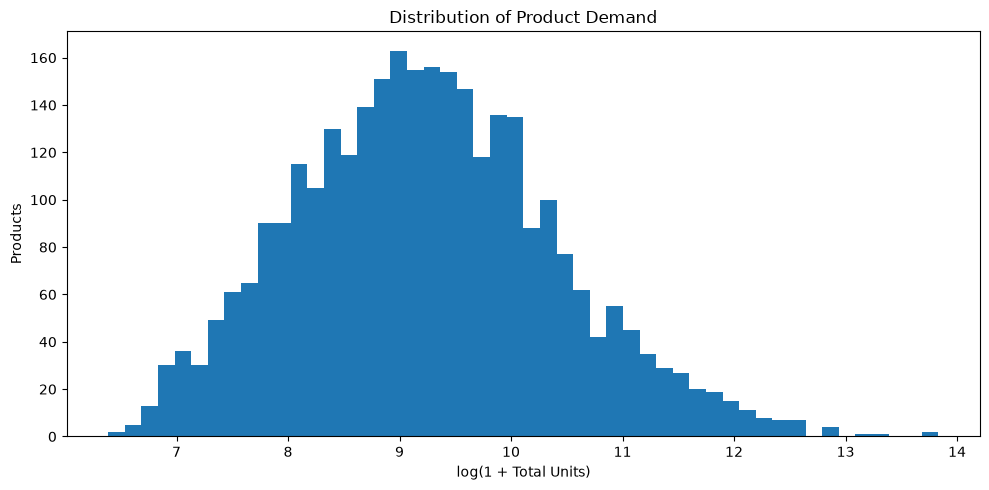

Top 10 share: 7.74%
Top 100 share: 29.63%


In [12]:
product_totals = sales[["item_id"] + day_columns].groupby("item_id", as_index=False)[day_columns].sum()
product_totals["total_units"] = product_totals[day_columns].sum(axis=1)
product_summary = product_totals[["item_id","total_units"]].sort_values("total_units", ascending=False).reset_index(drop=True)
display(product_summary.head(20))
fig, ax = plt.subplots(figsize=(10,5)); ax.hist(np.log1p(product_summary["total_units"]), bins=50); ax.set(title="Distribution of Product Demand", xlabel="log(1 + Total Units)", ylabel="Products"); plt.tight_layout(); plt.show()
total = product_summary["total_units"].sum(); print(f"Top 10 share: {product_summary.head(10)['total_units'].sum()/total:.2%}"); print(f"Top 100 share: {product_summary.head(100)['total_units'].sum()/total:.2%}")

## 12. Zero-Sales / Intermittent Demand

count    30490.000000
mean         0.679978
std          0.223406
min          0.001546
25%          0.534776
50%          0.733127
75%          0.865018
max          0.993818
Name: zero_sales_share, dtype: float64

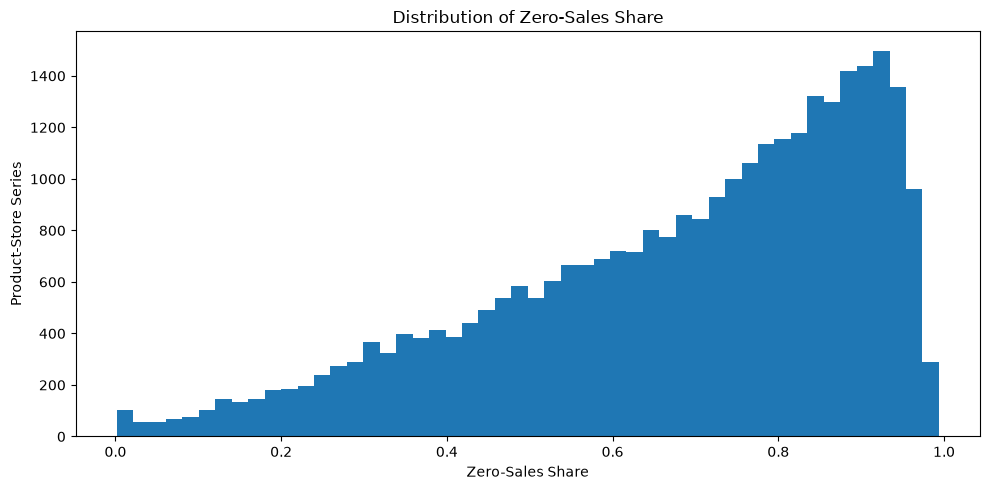

,cat_id,zero_sales_share
1,HOBBIES,0.771492
2,HOUSEHOLD,0.716022
0,FOODS,0.617734


In [13]:
zero_sales_summary = sales[["item_id","store_id","cat_id","dept_id"]].copy()
zero_sales_summary["zero_sales_share"] = sales[day_columns].eq(0).mean(axis=1)
display(zero_sales_summary["zero_sales_share"].describe())
fig, ax = plt.subplots(figsize=(10,5)); ax.hist(zero_sales_summary["zero_sales_share"], bins=50); ax.set(title="Distribution of Zero-Sales Share", xlabel="Zero-Sales Share", ylabel="Product-Store Series"); plt.tight_layout(); plt.show()
display(zero_sales_summary.groupby("cat_id", as_index=False)["zero_sales_share"].mean().sort_values("zero_sales_share", ascending=False))

## 13. Price Behavior

In [14]:
item_hierarchy = sales[["item_id","cat_id","dept_id"]].drop_duplicates()
price_with_category = prices.merge(item_hierarchy, on="item_id", how="left", validate="many_to_one")
display(price_with_category["sell_price"].describe()); display(price_with_category.groupby("cat_id")["sell_price"].describe())
price_sorted = prices.sort_values(["store_id","item_id","wm_yr_wk"]).copy()
price_sorted["previous_price"] = price_sorted.groupby(["store_id","item_id"])["sell_price"].shift(1)
price_sorted["price_changed"] = price_sorted["previous_price"].notna() & (price_sorted["sell_price"] != price_sorted["previous_price"])
comparable=price_sorted["previous_price"].notna(); print("Observed changes:", f"{price_sorted['price_changed'].sum():,}"); print("Comparable observations changed:", f"{price_sorted.loc[comparable,'price_changed'].mean():.2%}")

count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

,count,mean,std,min,25%,50%,75%,max
cat_id,,,,,,,,
FOODS,3181789.0,3.251027,2.132220,0.01,1.98,2.68,3.98,19.48
HOBBIES,1283905.0,5.333896,4.828999,0.01,1.97,3.97,7.47,30.98
HOUSEHOLD,2375427.0,5.465780,3.375843,0.01,2.98,4.94,6.97,107.32


Observed changes: 78,815
Comparable observations changed: 1.16%


## 14. Aggregate Price vs. Demand

A raw correlation is exploratory only and is **not** causal price elasticity.

,units_sold,average_sell_price
units_sold,1.0000,0.7629
average_sell_price,0.7629,1.0000


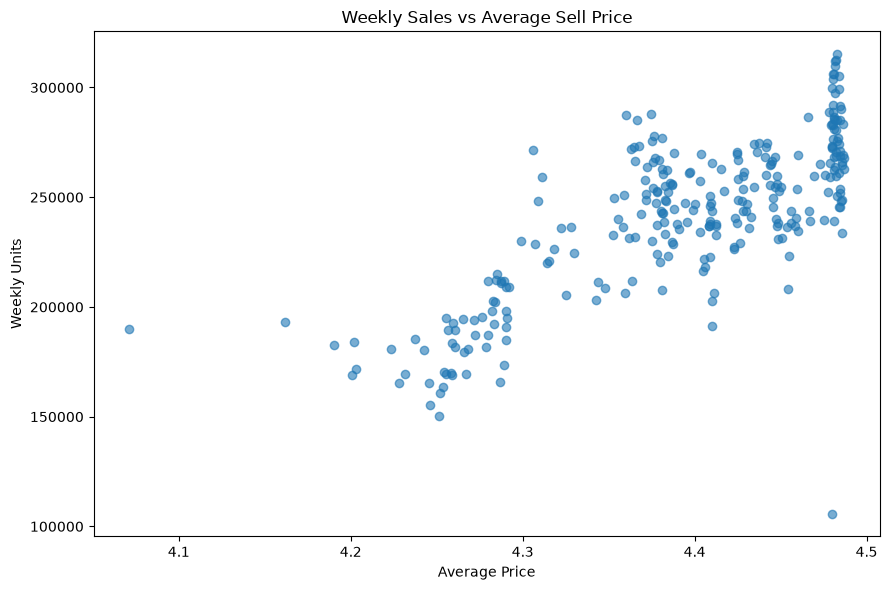

In [15]:
weekly_sales = daily_total.groupby("wm_yr_wk", as_index=False)["units_sold"].sum()
weekly_price = prices.groupby("wm_yr_wk", as_index=False)["sell_price"].mean().rename(columns={"sell_price":"average_sell_price"})
weekly_sales_price = weekly_sales.merge(weekly_price, on="wm_yr_wk", how="inner", validate="one_to_one")
display(weekly_sales_price[["units_sold","average_sell_price"]].corr())
fig, ax = plt.subplots(figsize=(9,6)); ax.scatter(weekly_sales_price["average_sell_price"], weekly_sales_price["units_sold"], alpha=.6); ax.set(title="Weekly Sales vs Average Sell Price", xlabel="Average Price", ylabel="Weekly Units"); plt.tight_layout(); plt.show()

## 15. M5 Event Effects

In [16]:
daily_total["has_event"] = daily_total["event_name_1"].notna()
display(daily_total.groupby("has_event", as_index=False)["units_sold"].agg(average_units="mean", median_units="median", days="count"))
display(daily_total.dropna(subset=["event_type_1"]).groupby("event_type_1", as_index=False)["units_sold"].agg(average_units="mean", days="count").sort_values("average_units", ascending=False))
display(daily_total.dropna(subset=["event_name_1"]).groupby("event_name_1", as_index=False)["units_sold"].agg(average_units="mean", days="count").sort_values("average_units", ascending=False).head(20))

,has_event,average_units,median_units,days
0,False,34609.336511,33817.0,1783
1,True,33029.911392,33956.5,158


,event_type_1,average_units,days
3,Sporting,35796.062500,16
0,Cultural,34718.594595,37
2,Religious,34426.240741,54
1,National,29458.509804,51


,event_name_1,average_units,days
10,LaborDay,42154.600000,5
20,OrthodoxEaster,41228.000000,5
26,SuperBowl,40924.000000,6
4,Easter,39517.600000,5
7,Father's day,36562.000000,4
21,Pesach End,36280.000000,6
15,Mother's day,36111.000000,6
23,Purim End,35957.000000,6
5,Eid al-Fitr,35267.600000,5
3,ColumbusDay,35164.800000,5


## 16. External U.S. Holiday Effects

In [17]:
daily_holiday = daily_total[["date","units_sold"]].merge(holidays, on="date", how="left")
daily_holiday["is_us_holiday"] = daily_holiday["holiday_name"].notna()
display(daily_holiday.groupby("is_us_holiday", as_index=False)["units_sold"].agg(average_units="mean", median_units="median", days="count"))
display(daily_holiday.dropna(subset=["holiday_name"]).groupby("holiday_name", as_index=False)["units_sold"].agg(average_units="mean", days="count").sort_values("average_units", ascending=False).head(20))

,is_us_holiday,average_units,median_units,days
0,False,34610.995228,33904.5,1886
1,True,30015.200000,32706.0,55


,holiday_name,average_units,days
4,Independence Day (observed),54154.000000,1
5,Labor Day,42154.600000,5
2,Columbus Day,35164.800000,5
11,Veterans Day,35118.800000,5
13,Washington's Birthday,34446.333333,6
3,Independence Day,33710.800000,5
6,Martin Luther King Jr. Day,33378.600000,5
12,Veterans Day (observed),33213.000000,1
9,New Year's Day (observed),33053.000000,1
7,Memorial Day,32699.600000,5


## 17. SNAP Effects

In [18]:
state_calendar = calendar_lookup[["d","date","snap_CA","snap_TX","snap_WI"]].copy()
snap_long = state_calendar.melt(id_vars=["d","date"], value_vars=["snap_CA","snap_TX","snap_WI"], var_name="snap_state", value_name="snap")
snap_long["state_id"] = snap_long["snap_state"].str.replace("snap_","",regex=False)
snap_analysis = daily_state.merge(snap_long[["date","state_id","snap"]], on=["date","state_id"], how="left", validate="one_to_one")
display(snap_analysis.groupby(["state_id","snap"], as_index=False)["units_sold"].mean())

,state_id,snap,units_sold
0,CA,0,14657.744812
1,CA,1,15823.423437
2,TX,0,9543.856264
3,TX,1,10643.512500
4,WI,0,8892.503459
5,WI,1,10832.662500


## 18. Weather Relationships

Weather correlations are exploratory associations, not proof of causation.

units_sold            1.000000
temperature_2m_max    0.279704
temperature_2m_min    0.111780
snowfall_sum         -0.103637
precipitation_sum    -0.124963
wind_speed_10m_max   -0.406958
Name: units_sold, dtype: float64

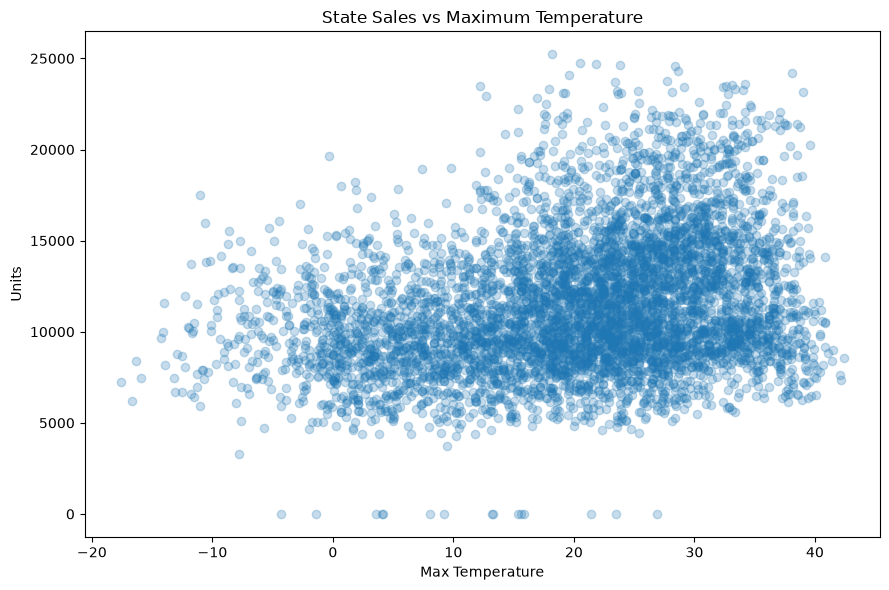

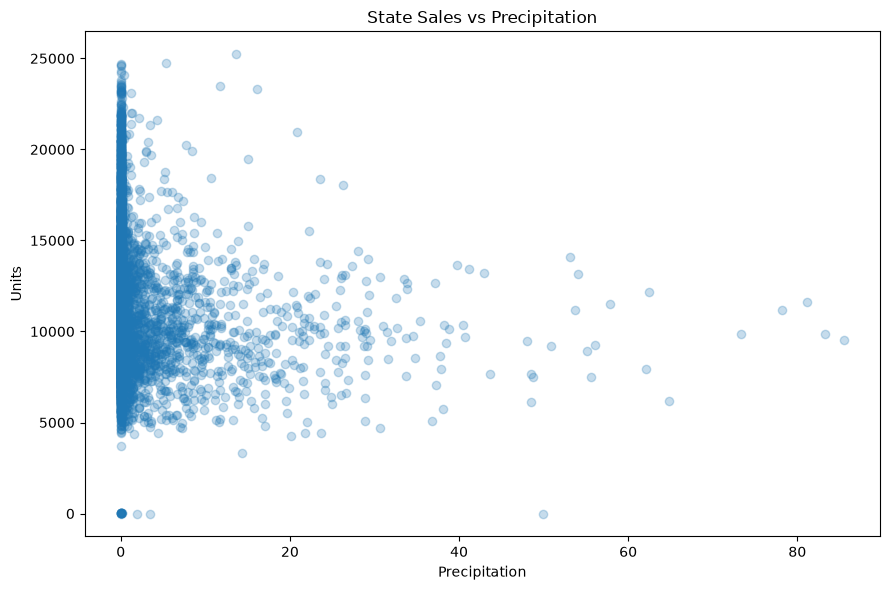

In [19]:
weather_analysis = weather.rename(columns={"time":"date"}).copy()
state_weather_sales = daily_state.merge(weather_analysis, on=["date","state_id"], how="inner", validate="one_to_one")
weather_columns=["temperature_2m_max","temperature_2m_min","precipitation_sum","snowfall_sum","wind_speed_10m_max"]
display(state_weather_sales[["units_sold"]+weather_columns].corr()["units_sold"].sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(9,6)); ax.scatter(state_weather_sales["temperature_2m_max"], state_weather_sales["units_sold"], alpha=.25); ax.set(title="State Sales vs Maximum Temperature", xlabel="Max Temperature", ylabel="Units"); plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(9,6)); ax.scatter(state_weather_sales["precipitation_sum"], state_weather_sales["units_sold"], alpha=.25); ax.set(title="State Sales vs Precipitation", xlabel="Precipitation", ylabel="Units"); plt.tight_layout(); plt.show()

## 19. Economic Context

series_id,CPIAUCSL,FEDFUNDS,UNRATE
date,,,
2011-01-01,221.187,0.17,9.1
2011-02-01,221.898,0.16,9.0
2011-03-01,223.046,0.14,9.0
2011-04-01,224.093,0.10,9.1
2011-05-01,224.806,0.09,9.0


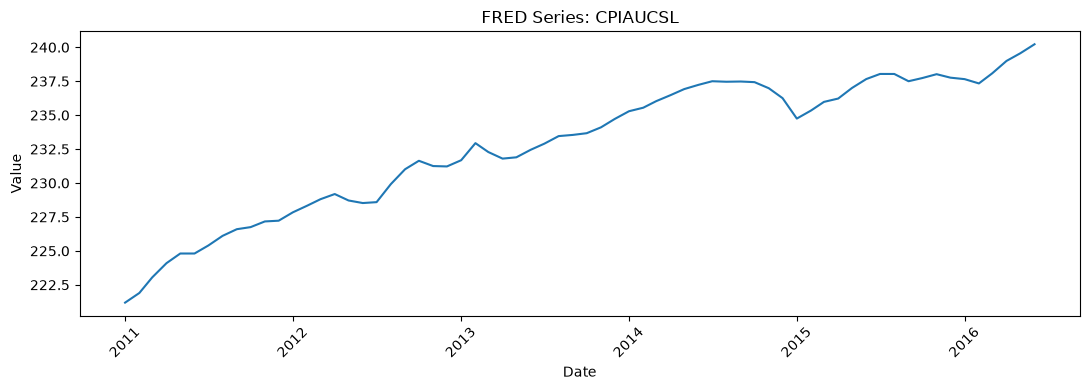

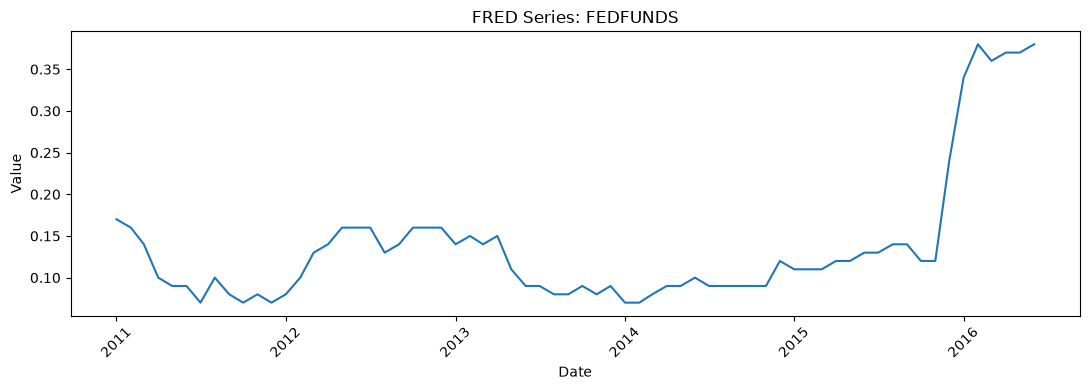

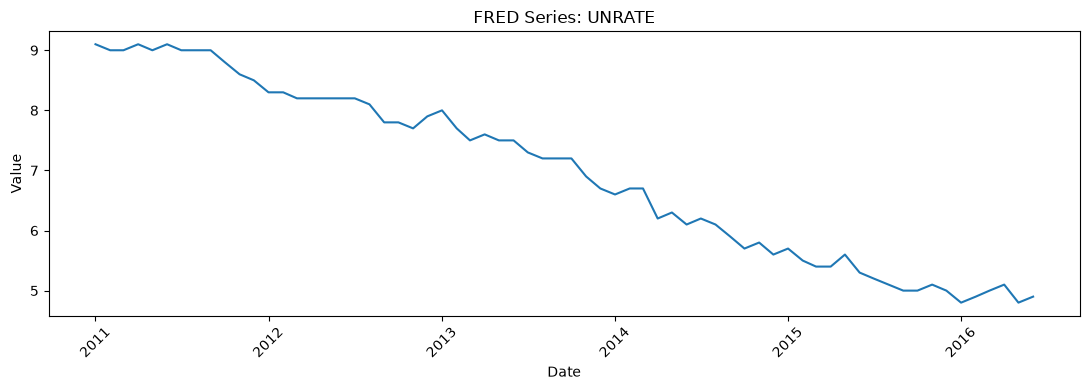

In [20]:
fred_pivot = fred.pivot(index="date", columns="series_id", values="value").sort_index()
display(fred_pivot.head())
for series_id in fred_pivot.columns:
    fig, ax = plt.subplots(figsize=(11,4)); ax.plot(fred_pivot.index, fred_pivot[series_id]); ax.set(title=f"FRED Series: {series_id}", xlabel="Date", ylabel="Value"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 20. Exploratory Economic Relationships

Monthly time-series correlations should be interpreted cautiously because common trends can create misleading correlation.

In [21]:
monthly_demand = daily_total[["date","units_sold"]].set_index("date").resample("MS")["units_sold"].sum().rename("monthly_units_sold").reset_index()
monthly_economic = monthly_demand.merge(fred_pivot.reset_index(), on="date", how="inner", validate="one_to_one")
display(monthly_economic.head())
display(monthly_economic[["monthly_units_sold","CPIAUCSL","UNRATE","FEDFUNDS"]].corr())

,date,monthly_units_sold,CPIAUCSL,FEDFUNDS,UNRATE
0,2011-01-01,88163,221.187,0.17,9.1
1,2011-02-01,726375,221.898,0.16,9.0
2,2011-03-01,763567,223.046,0.14,9.0
3,2011-04-01,737713,224.093,0.10,9.1
4,2011-05-01,719562,224.806,0.09,9.0


,monthly_units_sold,CPIAUCSL,UNRATE,FEDFUNDS
monthly_units_sold,1.000000,0.814658,-0.713465,0.213683
CPIAUCSL,0.814658,1.000000,-0.946543,0.277331
UNRATE,-0.713465,-0.946543,1.000000,-0.394695
FEDFUNDS,0.213683,0.277331,-0.394695,1.000000


## 21. Example Product-Store Demand Series

Example item: FOODS_3_090
Example store: CA_3


,item_id,store_id,d,units_sold,date
19362,FOODS_3_090,CA_3,d_1937,69,2016-05-18
19372,FOODS_3_090,CA_3,d_1938,75,2016-05-19
19382,FOODS_3_090,CA_3,d_1939,110,2016-05-20
19392,FOODS_3_090,CA_3,d_1940,156,2016-05-21
19402,FOODS_3_090,CA_3,d_1941,99,2016-05-22


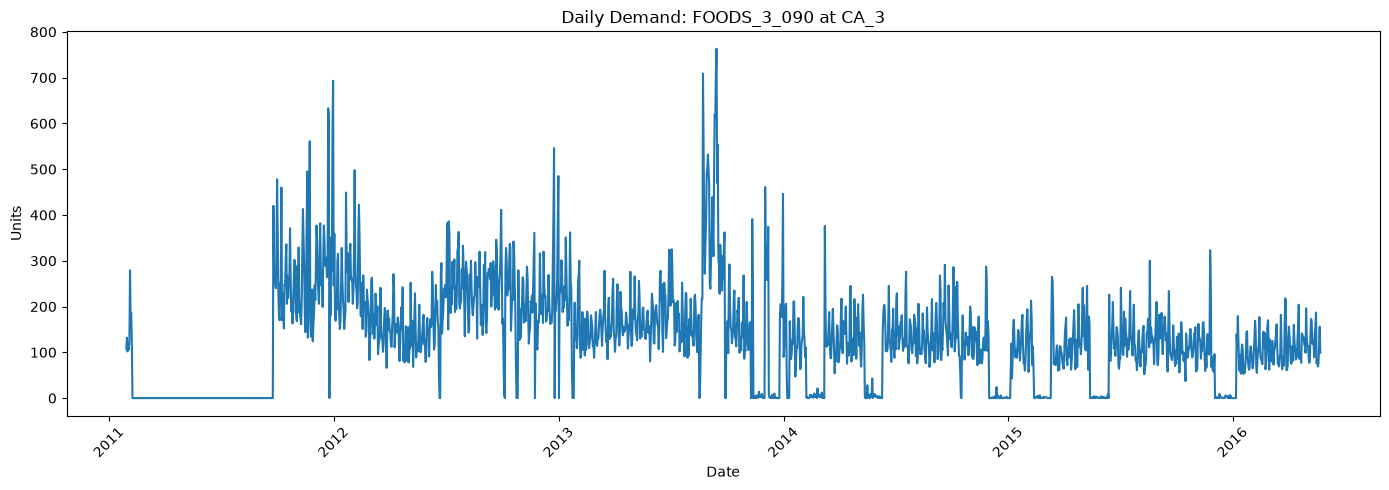

In [22]:
top_item = product_summary.iloc[0]["item_id"]
top_item_rows = sales.loc[sales["item_id"] == top_item, ["item_id","store_id"] + day_columns].copy()
top_item_long = top_item_rows.melt(id_vars=["item_id","store_id"], value_vars=day_columns, var_name="d", value_name="units_sold").merge(calendar_lookup[["d","date"]], on="d", how="left", validate="many_to_one")
example_store = top_item_long.groupby("store_id")["units_sold"].sum().idxmax()
example_series = top_item_long[top_item_long["store_id"] == example_store].sort_values("date").copy()
print("Example item:", top_item); print("Example store:", example_store); display(example_series.tail())
fig, ax = plt.subplots(figsize=(14,5)); ax.plot(example_series["date"], example_series["units_sold"]); ax.set(title=f"Daily Demand: {top_item} at {example_store}", xlabel="Date", ylabel="Units"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 22. Candidate Feature Ideas

The EDA suggests the following feature groups are worth testing in Notebook 03. These are candidates, not automatic inclusions; final features should be retained only when they improve time-based validation performance.

### Historical Demand
- lag 1, 7, 14, and 28 days
- rolling 7-day and 28-day averages
- rolling variability
- recent zero-sales behavior

### Calendar
- day of week, month, year, weekend
- M5 event name / event type
- U.S. holiday indicator
- SNAP eligibility by state

### Product / Store
- item, department, category, store, and state

### Price
- current and previous price
- absolute and percentage price change
- price relative to a recent reference price

### Weather
- temperature, precipitation, snowfall, and wind

### Economics
- CPI, unemployment, and federal funds rate

**Important:** lag and rolling features must use only information available before the prediction date to prevent data leakage.


## 23. EDA Findings

### Demand Behavior
- Product-store demand is highly intermittent. The mean zero-sales share is approximately **68%**, so many series contain frequent zero-demand days.
- Individual product-store series show sharp spikes, low-demand stretches, and changing demand levels over time.
- This makes recent demand history especially important for forecasting.

### Product Hierarchy
- Zero-sales behavior differs by category: **HOBBIES (~77%)**, **HOUSEHOLD (~72%)**, and **FOODS (~62%)**.
- Category, department, item, store, and state identifiers should remain available as candidate modeling features.

### Price
- Sell prices vary substantially across categories and products.
- Only about **1.16%** of comparable weekly price observations changed, so price is relatively stable for many item-store-week combinations.
- Aggregate weekly average price and total sales have a strong positive raw correlation (**~0.76**), but this is exploratory and must **not** be interpreted as causal price elasticity.

### Events / Holidays / SNAP
- M5 event types and individual events show different average demand levels, supporting event-based calendar features.
- Individual event estimates should be interpreted cautiously because many events occur only a small number of times.
- SNAP days have higher average sales in **CA, TX, and WI**, making SNAP a strong candidate feature.

### Weather
- Maximum temperature has a modest positive raw relationship with sales (**~0.28**).
- Precipitation (**~-0.12**), snowfall (**~-0.10**), and maximum wind speed (**~-0.41**) show negative raw relationships.
- These are exploratory associations rather than evidence of causation, but weather variables are reasonable candidates to test.

### Economics
- Monthly demand is positively correlated with CPI (**~0.81**) and negatively correlated with unemployment (**~-0.71**); the federal funds rate relationship is weaker (**~0.21**).
- These correlations must be treated cautiously because common time trends can create misleading relationships.
- Economic variables should be tested during modeling and retained only if they improve out-of-time validation.

### Modeling Implications
- **Highest-priority features:** lagged demand, rolling demand statistics, recent zero-sales behavior, calendar variables, product/store hierarchy, events, and SNAP.
- **Secondary features to test:** price, weather, and macroeconomic variables.
- **Primary modeling risks:** intermittent demand, large spikes, changing demand levels, sparse event observations, spurious aggregate correlations, and data leakage.
- Model evaluation should use **time-based validation**, not a random train/test split.


## 24. Next Step

EDA is complete. Move to `03_feature_engineering.ipynb`, where these findings will be converted into model-ready features.

Notebook 03 should begin with the highest-value signals identified here: **lags, rolling statistics, recent zero-sales behavior, calendar/event variables, SNAP, product/store hierarchy, and price features**. Weather and economic variables can then be added and evaluated through time-based validation.

All historical-demand features must be shifted so that a row for date *t* never uses sales information from date *t* or the future.
